In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.mixture import GaussianMixture

/var/folders/79/nr2svt5129sgxh5c4s_xdpx40000gp/T/ipykernel_6151/3673286299.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0, 0], palette='viridis')


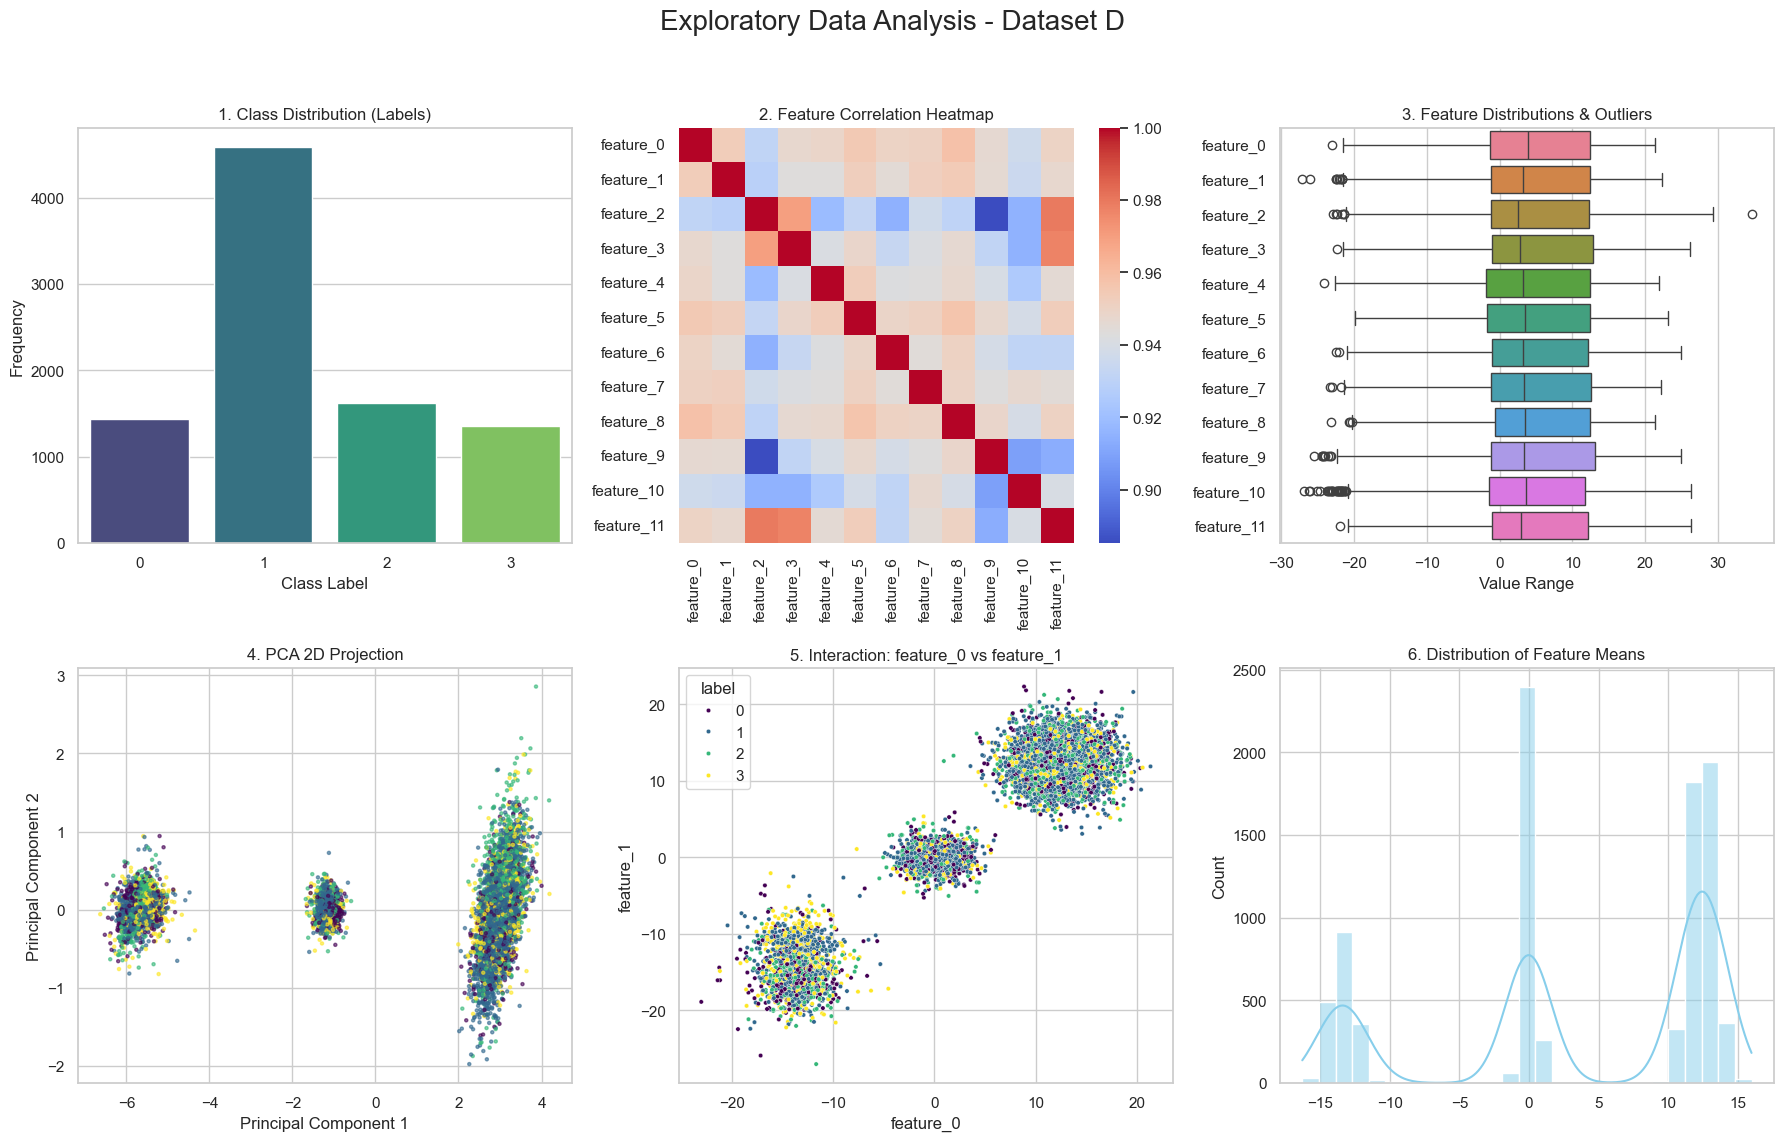

In [8]:
# Load the dataset
df = pd.read_csv("D.csv")

# Extract features and labels
X = df.drop(columns=['id', 'label'], errors='ignore')
y = df['label']

def perform_eda(df, X, y):
    """
    Performs Exploratory Data Analysis (EDA) and saves a dashboard of 6 plots.
    """
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Exploratory Data Analysis - Dataset D', fontsize=20)

    # Plot 1: Class Distribution
    sns.countplot(x=y, ax=axes[0, 0], palette='viridis')
    axes[0, 0].set_title('1. Class Distribution (Labels)')
    axes[0, 0].set_xlabel('Class Label')
    axes[0, 0].set_ylabel('Frequency')

    # Plot 2: Correlation Heatmap
    sns.heatmap(X.corr(), annot=False, cmap='coolwarm', ax=axes[0, 1])
    axes[0, 1].set_title('2. Feature Correlation Heatmap')

    # Plot 3: Boxplots
    sns.boxplot(data=X, ax=axes[0, 2], orient='h')
    axes[0, 2].set_title('3. Feature Distributions & Outliers')
    axes[0, 2].set_xlabel('Value Range')

    # Plot 4: PCA Projection
    X_scaled = StandardScaler().fit_transform(X)
    pca_res = PCA(n_components=2).fit_transform(X_scaled)
    axes[1, 0].scatter(pca_res[:, 0], pca_res[:, 1], c=y, cmap='viridis', s=5, alpha=0.6)
    axes[1, 0].set_title('4. PCA 2D Projection')
    axes[1, 0].set_xlabel('Principal Component 1')
    axes[1, 0].set_ylabel('Principal Component 2')

    # Plot 5: Feature Interaction (Example: feature_0 vs feature_1)
    sns.scatterplot(data=df, x='feature_0', y='feature_1', hue='label', ax=axes[1, 1], palette='viridis', s=10)
    axes[1, 1].set_title('5. Interaction: feature_0 vs feature_1')

    # Plot 6: Distribution of Mean Values
    sns.histplot(X.mean(axis=1), kde=True, ax=axes[1, 2], color='skyblue')
    axes[1, 2].set_title('6. Distribution of Feature Means')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("eda_plots.png", dpi=300)
    plt.show()

# Perform EDA
perform_eda(df, X, y)

In [9]:
# 2. Validation Strategy
# We use Stratified K-Fold to maintain the class distribution (Class 1 dominance) in every fold.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_baseline_task(X, y):
    print("--- Task 3: Baseline Model (KNN) ---")
    
    # --- Step A: Hyperparameter Search (Finding the best K) ---
    best_k = 1
    best_score = -1
    k_candidates = [1, 3, 5, 7, 9, 11, 15, 21] # Odd numbers to avoid ties
    
    print("Searching for optimal K...")
    for k in k_candidates:
        # Pipeline prevents label leakage: StandardScaler is fitted ONLY on training folds
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=k))
        ])
        
        # We optimize for 'f1_macro' as this is the leaderboard metric
        cv_results = cross_validate(pipeline, X, y, cv=skf, scoring='f1_macro')
        mean_f1 = cv_results['test_score'].mean()
        
        print(f"  K={k:2d} | Mean Macro-F1: {mean_f1:.4f}")
        
        if mean_f1 > best_score:
            best_score = mean_f1
            best_k = k

    print(f"\n-> Selected Best K: {best_k} with Macro-F1: {best_score:.4f}")
    
    # --- Step B: Final Evaluation (Per-Class Metrics) ---
    # We use the best K to generate a full classification report
    final_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k))
    ])
    
    # cross_val_predict allows us to get predictions for the whole dataset 
    # using the validation strategy, without leaking data.
    y_pred = cross_val_predict(final_pipeline, X, y, cv=skf)
    
    print(f"\n--- Final Baseline Classification Report (K={best_k}) ---")
    # This prints Precision, Recall, F1, and Accuracy for each class + Macro Avg
    print(classification_report(y, y_pred, digits=4))
    
    # Explicit check of the unweighted average
    macro_f1 = f1_score(y, y_pred, average='macro')
    print(f"Calculated Macro F1 Score: {macro_f1:.4f}")

run_baseline_task(X, y)

--- Task 3: Baseline Model (KNN) ---
Searching for optimal K...
  K= 1 | Mean Macro-F1: 0.5066
  K= 3 | Mean Macro-F1: 0.5286
  K= 5 | Mean Macro-F1: 0.5388
  K= 7 | Mean Macro-F1: 0.5438
  K= 9 | Mean Macro-F1: 0.5462
  K=11 | Mean Macro-F1: 0.5428
  K=15 | Mean Macro-F1: 0.5441
  K=21 | Mean Macro-F1: 0.5356

-> Selected Best K: 9 with Macro-F1: 0.5462

--- Final Baseline Classification Report (K=9) ---
              precision    recall  f1-score   support

           0     0.6213    0.4396    0.5149      1433
           1     0.6758    0.8815    0.7651      4584
           2     0.5515    0.4782    0.5122      1625
           3     0.6432    0.2828    0.3928      1358

    accuracy                         0.6480      9000
   macro avg     0.6229    0.5205    0.5463      9000
weighted avg     0.6397    0.6480    0.6234      9000

Calculated Macro F1 Score: 0.5463


--- Step 1: Training Outlier Detector (GMM) ---
Mean Score Train (Inlier): -20.28
Mean Score D_out (Outlier): -31.57
Determined Threshold Tau: -21.3931


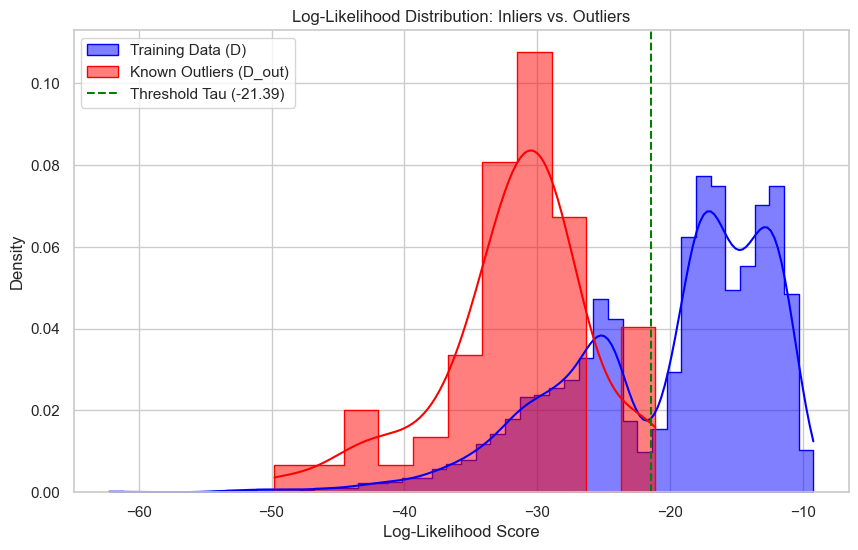


--- Step 2: Cleaning Training Data ---
Original Training Size: 9000
Cleaned Training Size: 5661
Removed 3339 noisy samples (37.10%)

--- Step 3: Training Final Classifier (Random Forest) ---
Saved submission to submission_leaderboard_Group17.csv
Saved submission to submission_final_Group17.csv


In [13]:
# 1. Daten laden
df_train = pd.read_csv("D.csv")
df_out_ref = pd.read_csv("D_out.csv") # Unsere Referenz für "Böse Daten"

# Features extrahieren
X_train = df_train.drop(columns=['id', 'label'], errors='ignore')
y_train = df_train['label']
X_out_ref = df_out_ref.drop(columns=['id'], errors='ignore')

print("--- Step 1: Training Outlier Detector (GMM) ---")
# Wir nutzen ein GMM, um die "normale" Datenverteilung zu lernen.
# n_components=4 passt gut, da wir 4 Klassen haben.
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm.fit(X_train)

# Scores berechnen (Log-Likelihood)
# Je niedriger der Score, desto unwahrscheinlicher (abnormaler) ist der Punkt.
scores_train = gmm.score_samples(X_train)
scores_out_ref = gmm.score_samples(X_out_ref)

print(f"Mean Score Train (Inlier): {scores_train.mean():.2f}")
print(f"Mean Score D_out (Outlier): {scores_out_ref.mean():.2f}")

# Bestimme Threshold Tau
# Strategie: Wir setzen Tau so, dass wir fast alle bekannten Outlier (D_out) erwischen.
# Wir nehmen das 99. Perzentil der Outlier-Scores als Grenze.
tau = np.percentile(scores_out_ref, 99)
print(f"Determined Threshold Tau: {tau:.4f}")

# Visualisierung für den Bericht (Task 5)
plt.figure(figsize=(10, 6))
sns.histplot(scores_train, color='blue', label='Training Data (D)', kde=True, stat="density", element="step")
sns.histplot(scores_out_ref, color='red', label='Known Outliers (D_out)', kde=True, stat="density", element="step")
plt.axvline(tau, color='green', linestyle='--', label=f'Threshold Tau ({tau:.2f})')
plt.title("Log-Likelihood Distribution: Inliers vs. Outliers")
plt.xlabel("Log-Likelihood Score")
plt.legend()
plt.savefig("task5_outlier_distribution.png")
plt.show()

print("\n--- Step 2: Cleaning Training Data ---")
# Wir entfernen "versteckte" Outlier aus unserem Trainingsset D!
# Das verbessert den Klassifikator massiv.
mask_clean = scores_train >= tau
X_train_clean = X_train[mask_clean]
y_train_clean = y_train[mask_clean]

n_removed = len(X_train) - len(X_train_clean)
print(f"Original Training Size: {len(X_train)}")
print(f"Cleaned Training Size: {len(X_train_clean)}")
print(f"Removed {n_removed} noisy samples ({n_removed/len(X_train)*100:.2f}%)")

print("\n--- Step 3: Training Final Classifier (Random Forest) ---")
# Wir trainieren auf den BEREINIGTEN Daten
final_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
final_clf.fit(X_train_clean, y_train_clean)

# Funktion für Vorhersagen (Leaderboard Format)
def predict_pipeline(X_test_df):
    X_test = X_test_df.drop(columns=['id'], errors='ignore')
    
    # 1. Outlier Detection
    test_scores = gmm.score_samples(X_test)
    is_outlier = (test_scores < tau).astype(int)
    
    # 2. Classification (ignoriert Outlier eigentlich, aber wir müssen Labels liefern)
    labels = final_clf.predict(X_test)
    
    return labels, is_outlier

# Submission Generieren
def generate_and_save(filename_in, filename_out, group_name):
    df_test = pd.read_csv(filename_in)
    labels, outliers = predict_pipeline(df_test)
    
    sub_df = pd.DataFrame({
        "id": df_test["id"],
        "label": labels,
        "outlier": outliers
    })
    
    outfile = f"{filename_out}_{group_name}.csv"
    sub_df.to_csv(outfile, index=False)
    print(f"Saved submission to {outfile}")

# EXECUTE
group_name = "Group17" 
generate_and_save("D_test_leaderboard.csv", "submission_leaderboard", group_name)
generate_and_save("D_test_final.csv", "submission_final", group_name)